# Klasifikasi Citra Buah Menggunakan Metode K-Nearest Neighbor (KNN)


Nama : Almas Indhar Amanullah  
NIM : 2318110  

Dataset yang digunakan adalah citra buah dengan ekstraksi fitur warna RGB.
Metode Machine Learning yang digunakan adalah K-Nearest Neighbor (KNN).

# 1.Upload Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
dataset_path = "/content/drive/MyDrive/Dataset/Dataset Citra Buah"

# 2.Install Library

Import library:

In [35]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# 3.Menampilkan Contoh Citra Dataset

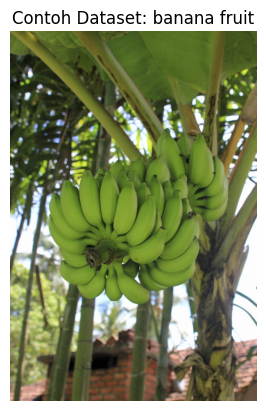

In [38]:
import random

folder = random.choice(os.listdir(dataset_path))
img_name = random.choice(os.listdir(os.path.join(dataset_path, folder)))

img_path = os.path.join(dataset_path, folder, img_name)

img = cv2.imread(img_path)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Contoh Dataset: " + folder)
plt.axis("off")
plt.show()

# 4.Ekstraksi Fitur RGB

In [39]:
data = []
labels = []

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    for file in os.listdir(folder_path):

        img_path = os.path.join(folder_path, file)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img,(64,64))

        mean_color = np.mean(img, axis=(0,1))

        data.append(mean_color)
        labels.append(folder)

# 5.Membuat Dataset Fitur

In [40]:
df = pd.DataFrame(data, columns=['R','G','B'])
df['Label'] = labels

df.head()

,R,G,B,Label
0,149.521729,197.714355,239.920410,orange fruit
1,129.866455,214.887207,247.724121,orange fruit
2,165.536621,210.927246,239.467773,orange fruit
3,80.315186,122.775146,190.823242,orange fruit
4,62.247559,201.690430,251.031494,orange fruit


# 6.Cek Jumlah Dataset

In [41]:
print("Jumlah total data:", len(df))

Jumlah total data: 360


# 7.Distribusi Dataset

In [42]:
df['Label'].value_counts()

,count
Label,
orange fruit,40
strawberry fruit,40
grapes fruit,40
kiwi fruit,40
chickoo fruit,40
apple fruit,40
banana fruit,40
cherry fruit,40
mango fruit,40


# 8.Simpan Dataset Fitur

In [43]:
df.to_csv("dataset_fitur_buah.csv", index=False)

# 9.Split Data Training dan Testing

In [44]:
X = df[['R','G','B']]
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Artinya:

80% data training
20% data testing

# 10.Training Model KNN

In [45]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

# 11.Prediksi Data Testing

In [46]:
y_pred = knn.predict(X_test)

# 12.Evaluasi Akurasi Model

In [47]:
accuracy = accuracy_score(y_test, y_pred)

print("Akurasi Model KNN:", accuracy)

Akurasi Model KNN: 0.3194444444444444


# 13.Confusion Matrix

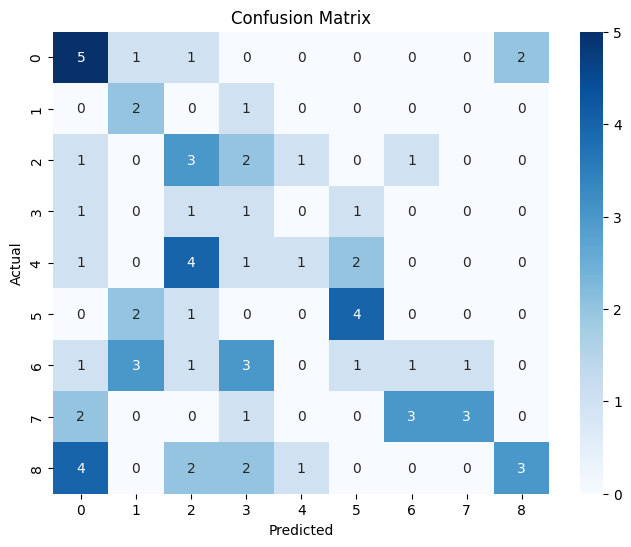

In [48]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 14.Uji Citra Baru

In [49]:
img_path = "/content/drive/MyDrive/Dataset Citra Buah/images/orange fruit/Image_12.jpg"

img_original = cv2.imread(img_path)

img = cv2.resize(img_original,(64,64))

mean = np.mean(img, axis=(0,1))

test = np.array(mean).reshape(1,-1)

pred = knn.predict(test)

print("Prediksi buah:", pred)

Prediksi buah: ['orange fruit']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


# 15.Menampilkan Gambar dan Hasil Prediksi

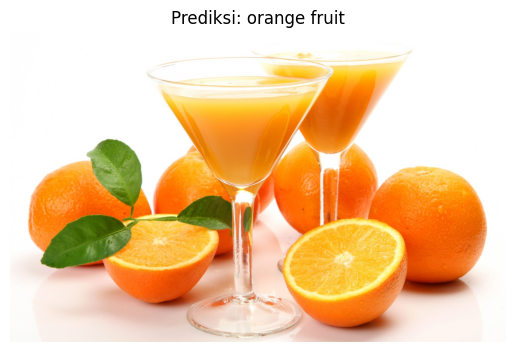

In [50]:
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.title("Prediksi: " + pred[0])
plt.axis("off")
plt.show()

# 16.Download CSV

In [53]:
from google.colab import files
files.download("dataset_fitur_buah.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>